# Stage 2 — EDA по frame-level данным

Что нового по сравнению со старым stage2 — добавлен анализ **длин последовательностей** (важно для выбора L и для понимания, сколько информации мы теряли усреднением) и **покадровая вариативность** (количественно показываем, почему усреднение "размыло кашу").

Разделы:
1. Распределение классов
2. Распределение длин последовательностей T
3. Покадровая вариативность (std между кадрами внутри видео)
4. PCA: frame-level vs. mean-pooled — сколько теряется
5. KNN baseline на усреднённых (повторяем старый) и на flatten первых 30 кадров

In [1]:
# ============================================================
# 2.0 — Загрузка
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import json, warnings
warnings.filterwarnings('ignore')

OUT_DIR = Path('../data2/frame_processed')
EDA_DIR = Path('../data2/frame_eda'); EDA_DIR.mkdir(exist_ok=True)
config  = json.load(open(OUT_DIR / 'config.json'))

L         = config['L']
GENRES    = config['genres']
N_CLASSES = config['n_classes']
DEQ_S     = config['dequant_scale']
DEQ_B     = config['dequant_bias']

X_rgb_q   = np.load(OUT_DIR / 'X_rgb.npy', mmap_mode='r')   # (N, L, 1024) uint8
X_audio_q = np.load(OUT_DIR / 'X_audio.npy', mmap_mode='r') # (N, L, 128)  uint8
lengths   = np.load(OUT_DIR / 'lengths.npy')
y         = np.load(OUT_DIR / 'y.npy')

N = len(y)
print(f'N={N:,}  L={L}  RGB(N,L,D)={X_rgb_q.shape}  AUD={X_audio_q.shape}')
print(f'lengths: min={lengths.min()} max={lengths.max()} mean={lengths.mean():.1f} median={np.median(lengths):.0f}')

N=4,939  L=60  RGB(N,L,D)=(4939, 60, 1024)  AUD=(4939, 60, 128)
lengths: min=1 max=60 mean=60.0 median=60


In [2]:
# ============================================================
# 2.1 — Стиль графиков
# ============================================================
PALETTE = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
           '#FF9F1C','#2EC4B6','#E71D36','#ACB5BD','#F72585',
           '#4CC9F0','#80B918']
plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D2E',
    'axes.edgecolor':'#2E3250','axes.labelcolor':'#C8D0F0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#8890B0',
    'ytick.color':'#8890B0','text.color':'#C8D0F0',
    'grid.color':'#2E3250','grid.linestyle':'--','grid.alpha':0.4,
    'figure.dpi':120,
})

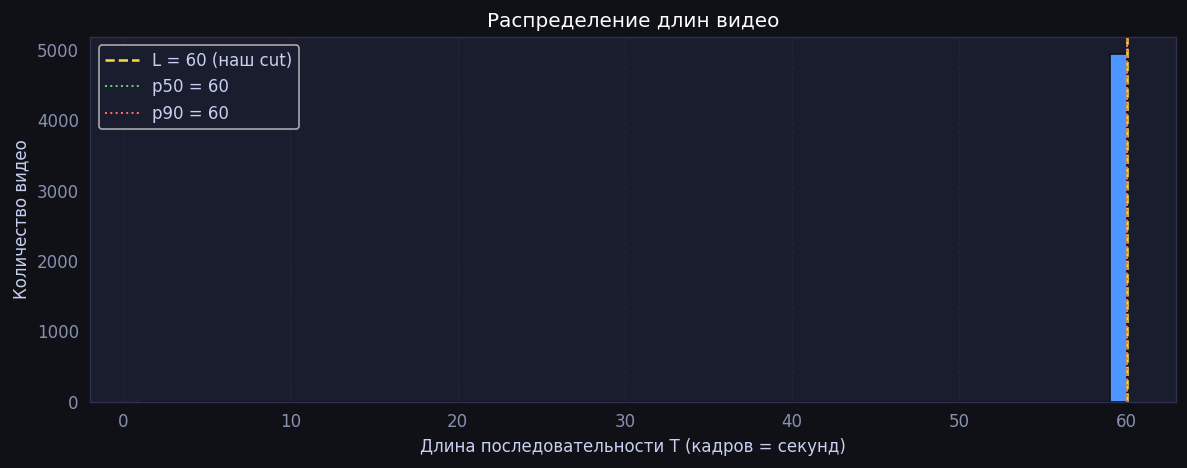

100.0% видео заполняют все L=60 слотов полностью
100.0% видео имеют >= L/2 = 30 кадров
p99 = 60 → если видео длиннее 60, мы теряем хвост


In [3]:
# ============================================================
# 2.2 — Распределение длин последовательностей
# ============================================================
# Важно: если перцентиль 90 >> L, значит урезаем много инфы.
# Если перцентиль 90 <= L — берём почти всё видео.

p50 = np.percentile(lengths, 50)
p90 = np.percentile(lengths, 90)
p99 = np.percentile(lengths, 99)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(lengths, bins=60, color='#4D96FF', edgecolor='#0F1117')
ax.axvline(L,  color='#FFD93D', ls='--', lw=1.5, label=f'L = {L} (наш cut)')
ax.axvline(p50, color='#6BCB77', ls=':',  lw=1.2, label=f'p50 = {p50:.0f}')
ax.axvline(p90, color='#FF6B6B', ls=':',  lw=1.2, label=f'p90 = {p90:.0f}')
ax.set_xlabel('Длина последовательности T (кадров = секунд)')
ax.set_ylabel('Количество видео')
ax.set_title('Распределение длин видео')
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig(EDA_DIR / '2_1_length_histogram.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

frac_full = (lengths >= L).mean() * 100
frac_half = (lengths >= L/2).mean() * 100
print(f'{frac_full:.1f}% видео заполняют все L={L} слотов полностью')
print(f'{frac_half:.1f}% видео имеют >= L/2 = {L//2} кадров')
print(f'p99 = {p99:.0f} → если видео длиннее {L}, мы теряем хвост')

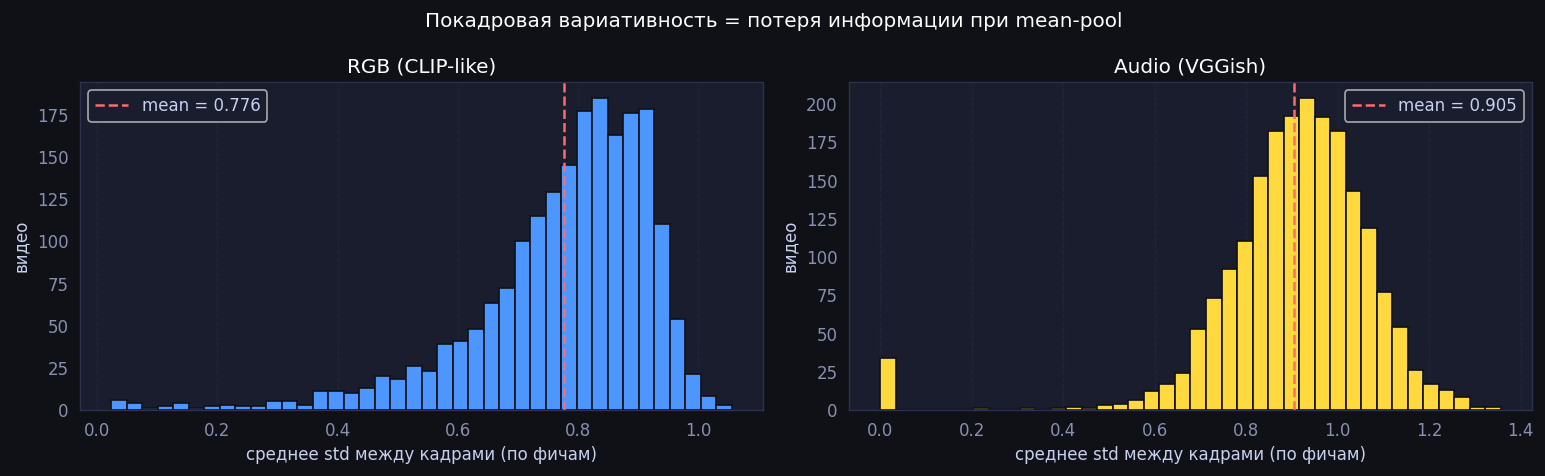

Среднее std между кадрами внутри видео:
  RGB   : 0.776   (значения фичей в [-2, 2])
  Audio : 0.905


In [4]:
# ============================================================
# 2.3 — Покадровая вариативность (сколько теряет усреднение)
# ============================================================
# Для каждого видео считаем std(frames, axis=0) — насколько разбросаны
# кадры относительно своего среднего. Если эта величина большая —
# mean-pool (старый подход) теряет много информации.

rng = np.random.default_rng(0)
subsample_idx = rng.choice(N, min(2000, N), replace=False)

inter_std_rgb   = []
inter_std_audio = []
for i in subsample_idx:
    T = lengths[i]
    if T < 2:
        continue
    # dequantize только реальные кадры
    r = X_rgb_q[i, :T].astype(np.float32) * DEQ_S + DEQ_B    # (T, 1024)
    a = X_audio_q[i, :T].astype(np.float32) * DEQ_S + DEQ_B  # (T, 128)
    inter_std_rgb.append(r.std(axis=0).mean())
    inter_std_audio.append(a.std(axis=0).mean())
inter_std_rgb   = np.array(inter_std_rgb)
inter_std_audio = np.array(inter_std_audio)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Покадровая вариативность = потеря информации при mean-pool',
             fontsize=12, color='white')
for ax, data, name, col in [
    (axes[0], inter_std_rgb,   'RGB (CLIP-like)', '#4D96FF'),
    (axes[1], inter_std_audio, 'Audio (VGGish)',  '#FFD93D'),
]:
    ax.hist(data, bins=40, color=col, edgecolor='#0F1117')
    ax.axvline(data.mean(), color='#FF6B6B', ls='--',
               label=f'mean = {data.mean():.3f}')
    ax.set_xlabel('среднее std между кадрами (по фичам)')
    ax.set_ylabel('видео')
    ax.set_title(name)
    ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig(EDA_DIR / '2_2_interframe_variance.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

print(f'Среднее std между кадрами внутри видео:')
print(f'  RGB   : {inter_std_rgb.mean():.3f}   (значения фичей в [-2, 2])')
print(f'  Audio : {inter_std_audio.mean():.3f}')

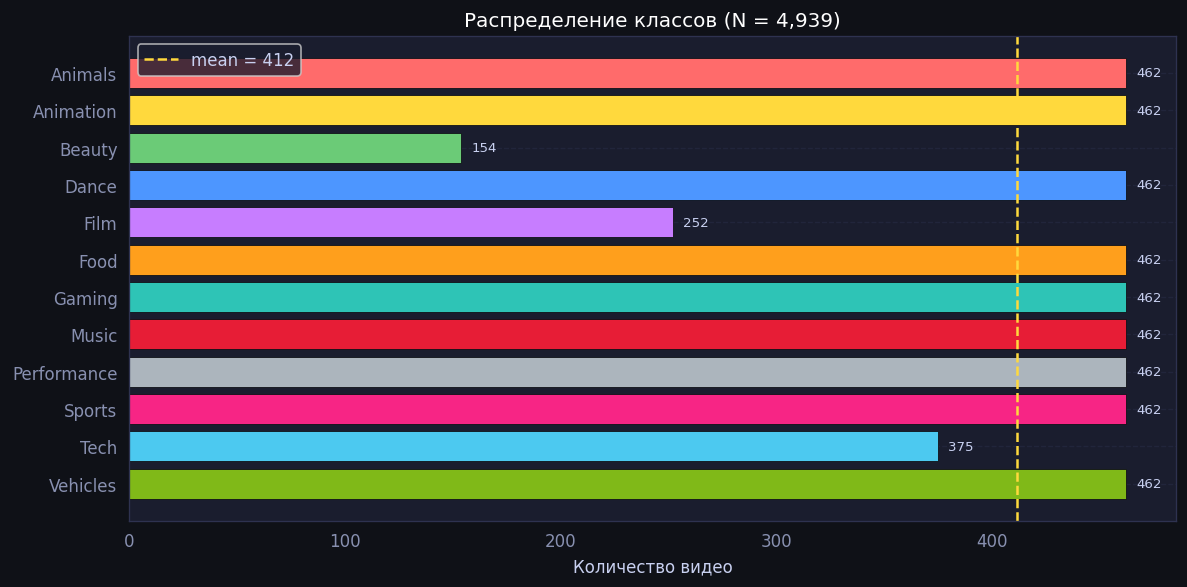

imbalance ratio: 3.00×


In [5]:
# ============================================================
# 2.4 — Распределение классов
# ============================================================
counts = np.bincount(y, minlength=N_CLASSES)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bars = ax.barh(GENRES, counts, color=PALETTE[:N_CLASSES],
               edgecolor='#0F1117', linewidth=0.5)
ax.set_xlabel('Количество видео')
ax.set_title(f'Распределение классов (N = {N:,})')
ax.invert_yaxis()
ax.axvline(counts.mean(), color='#FFD93D', ls='--',
           label=f'mean = {counts.mean():.0f}')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + counts.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=8)
ax.legend(); ax.grid(axis='x')
plt.tight_layout()
plt.savefig(EDA_DIR / '2_3_class_distribution.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'imbalance ratio: {counts.max()/max(counts.min(),1):.2f}×')

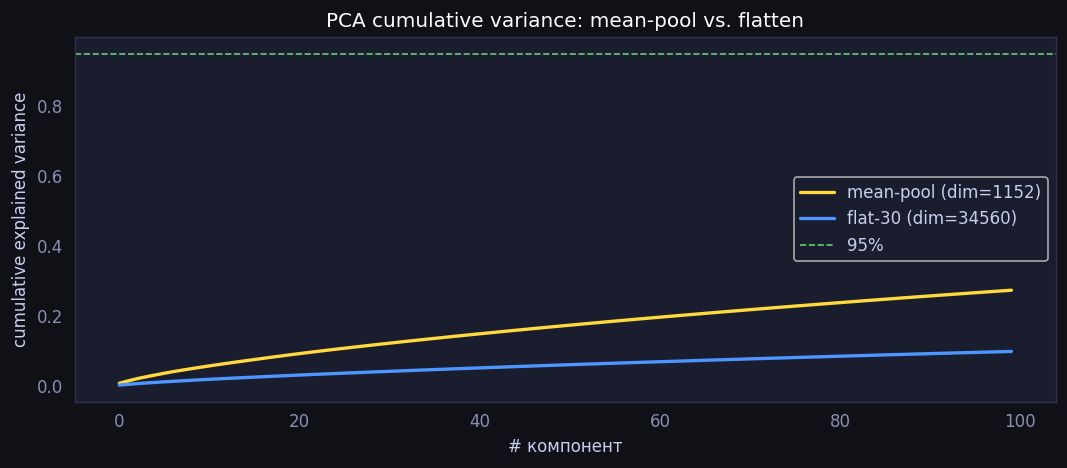

In [6]:
# ============================================================
# 2.5 — PCA: mean-pooled vs. flatten первых N кадров
# ============================================================
# Сравниваем два представления одного и того же видео:
#   mean   — (1024+128,) усреднённых по времени (как делали раньше)
#   flat30 — (30 × (1024+128),) = 34560 покадровые, сплюснутые
# Затем считаем PCA и смотрим cumulative variance.

FLAT_K = 30   # сколько первых кадров брать в flatten
SUBSAMPLE = min(5000, N)
sub_idx = rng.choice(N, SUBSAMPLE, replace=False)

# dequantize только нужное
def dequant(x_q): return x_q.astype(np.float32) * DEQ_S + DEQ_B

# mean-pool по реальным кадрам
X_mean = np.zeros((SUBSAMPLE, 1024 + 128), dtype=np.float32)
X_flat = np.zeros((SUBSAMPLE, FLAT_K * (1024 + 128)), dtype=np.float32)
for j, i in enumerate(sub_idx):
    T = lengths[i]
    r = dequant(np.array(X_rgb_q[i, :T]))
    a = dequant(np.array(X_audio_q[i, :T]))
    X_mean[j] = np.concatenate([r.mean(axis=0), a.mean(axis=0)])
    # flatten первых FLAT_K (паддинг нулями если короче)
    K = min(T, FLAT_K)
    X_flat[j, :K*1024] = r[:K].ravel()
    X_flat[j, FLAT_K*1024 : FLAT_K*1024 + K*128] = a[:K].ravel()

pca_mean = PCA(n_components=min(100, X_mean.shape[1])).fit(X_mean)
pca_flat = PCA(n_components=min(100, X_flat.shape[1])).fit(X_flat)

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(np.cumsum(pca_mean.explained_variance_ratio_), color='#FFD93D',
        label=f'mean-pool (dim={X_mean.shape[1]})', lw=2)
ax.plot(np.cumsum(pca_flat.explained_variance_ratio_), color='#4D96FF',
        label=f'flat-{FLAT_K} (dim={X_flat.shape[1]})', lw=2)
ax.axhline(0.95, color='#6BCB77', ls='--', lw=1, label='95%')
ax.set_xlabel('# компонент'); ax.set_ylabel('cumulative explained variance')
ax.set_title('PCA cumulative variance: mean-pool vs. flatten')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig(EDA_DIR / '2_4_pca_compare.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

In [7]:
# ============================================================
# 2.6 — KNN baseline: подтверждаем что flatten > mean-pool
# ============================================================
# Если flatten-представление реально несёт больше информации, KNN
# на нём должен быть заметно лучше чем на усреднённом.

y_sub = y[sub_idx]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('KNN (k=5, cosine) 5-fold CV на subsample=5000:')
for X, name in [(X_mean, 'mean-pool'), (X_flat, f'flat-{FLAT_K}')]:
    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
    acc = cross_val_score(knn, X, y_sub, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'  {name:<10}  acc = {acc.mean():.4f} ± {acc.std():.4f}')

KNN (k=5, cosine) 5-fold CV на subsample=5000:
  mean-pool   acc = 0.7281 ± 0.0219
  flat-30     acc = 0.6657 ± 0.0121


In [8]:
# ============================================================
# 2.7 — Сохранение результатов
# ============================================================
eda = {
    'n_samples'         : int(N),
    'L'                 : L,
    'length_min'        : int(lengths.min()),
    'length_max'        : int(lengths.max()),
    'length_mean'       : float(lengths.mean()),
    'length_p50'        : float(p50),
    'length_p90'        : float(p90),
    'length_p99'        : float(p99),
    'frac_full_L'       : float(frac_full),
    'interframe_std_rgb': float(inter_std_rgb.mean()),
    'interframe_std_aud': float(inter_std_audio.mean()),
    'class_counts'      : {g: int(c) for g, c in zip(GENRES, counts)},
    'imbalance_ratio'   : float(counts.max()/max(counts.min(),1)),
}
with open(EDA_DIR / 'eda_results.json', 'w') as f:
    json.dump(eda, f, indent=2, ensure_ascii=False)
print('EDA сохранён:', EDA_DIR)

EDA сохранён: ../data2/frame_eda
